In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import time
import pandas as pd
import os
import gc
import json

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

os.makedirs("images", exist_ok=True)
os.makedirs("/content/cache", exist_ok=True)   # disk-backed tf.data caches live here
RESULTS_CSV = "images/comparison_table.csv"     # shared checkpoint file across all 3 parts

available_fonts = {f.name for f in font_manager.fontManager.ttflist}
serif_font = "Times New Roman" if "Times New Roman" in available_fonts else \
             "Liberation Serif" if "Liberation Serif" in available_fonts else "DejaVu Serif"

mpl.rcParams.update({
    "font.family": "serif", "font.serif": [serif_font], "font.weight": "bold",
    "axes.titlesize": 16, "axes.titleweight": "bold",
    "axes.labelsize": 14, "axes.labelweight": "bold",
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11,
    "figure.figsize": (8, 6), "savefig.dpi": 600, "savefig.format": "eps", "savefig.bbox": "tight",
})

def make_bold_ticks(ax):
    for label in ax.get_xticklabels(): label.set_fontweight("bold")
    for label in ax.get_yticklabels(): label.set_fontweight("bold")

def save_figure(name):
    make_bold_ticks(plt.gca())
    plt.savefig(f"images/{name}.eps", format="eps", dpi=600, bbox_inches="tight")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print(f"Using {len(gpus)} GPU(s) with mixed precision.")
else:
    print("WARNING: No GPU detected.")

# Data — reloaded fresh every session, cheap (CIFAR-10 is ~170MB)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()
class_names = ['Airplane','Automobile','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']

def append_result_row(row, csv_path=RESULTS_CSV):
    """Checkpoints one model's result to disk immediately — survives kernel restarts."""
    df_row = pd.DataFrame([row])
    if os.path.exists(csv_path):
        df_row.to_csv(csv_path, mode='a', header=False, index=False)
    else:
        df_row.to_csv(csv_path, mode='w', header=True, index=False)
    print(f"Checkpointed: {row['Model']}")

def build_tf_dataset(x, y, img_size, preprocess_fn, batch_size=64, training=True, cache_mode="disk", cache_name=None):
    """
    cache_mode: 'disk'  -> cache to a file under /content/cache (default, RAM-safe)
                'memory'-> in-memory cache (only use for small native 32x32 data)
                'skip'  -> no caching (use for one-shot sweep configs that don't
                           benefit from caching and shouldn't accumulate RAM/disk use)
    """
    ds = tf.data.Dataset.from_tensor_slices((x, y))

    def _map(img, label):
        if img_size != 32:
            img = tf.image.resize(img, (img_size, img_size))
        if preprocess_fn is not None:
            img = preprocess_fn(img * 255.0)
        label = tf.one_hot(label, 10)
        return img, label

    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(5000, seed=SEED)

    if cache_mode == "disk":
        name = cache_name or f"ds_{img_size}_{'train' if training else 'test'}"
        ds = ds.cache(f"/content/cache/{name}")
    elif cache_mode == "memory":
        ds = ds.cache()
    # 'skip' -> no caching at all

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def train_and_time(model, train_ds, val_ds, epochs, model_name):
    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    elapsed = time.time() - start
    print(f"[{model_name}] Training time: {elapsed/60:.2f} min ({elapsed/epochs:.1f} s/epoch avg)")
    return history, elapsed

def evaluate_model(model, test_ds, y_true, model_name):
    y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n=== {model_name} — Test Set Performance ===")
    print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted', fontweight='bold'); plt.ylabel('Actual', fontweight='bold')
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    save_figure(f"confusion_matrix_{model_name.lower().replace(' ', '_')}")
    plt.show()
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "y_pred": y_pred}

def plot_training_curves(history_dict, model_name, fine_tune_epoch=None):
    epochs_range = range(len(history_dict['accuracy']))
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history_dict['accuracy'], label='Training')
    plt.plot(epochs_range, history_dict['val_accuracy'], label='Validation')
    if fine_tune_epoch is not None:
        plt.axvline(x=fine_tune_epoch, color='gray', linestyle='--', label='Fine-tune start')
    plt.title(f'{model_name} — Accuracy', fontweight='bold'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history_dict['loss'], label='Training')
    plt.plot(epochs_range, history_dict['val_loss'], label='Validation')
    if fine_tune_epoch is not None:
        plt.axvline(x=fine_tune_epoch, color='gray', linestyle='--', label='Fine-tune start')
    plt.title(f'{model_name} — Loss', fontweight='bold'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.tight_layout()
    save_figure(f"curves_{model_name.lower().replace(' ', '_')}")
    plt.show()

def plot_misclassified(model, test_ds, x_test_raw, y_true, model_name, n=10):
    y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
    idx = np.where(y_pred != y_true)[0][:n]
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for ax, i in zip(axes.flat, idx):
        ax.imshow(x_test_raw[i])
        ax.set_title(f"True: {class_names[y_true[i]]}\nPred: {class_names[y_pred[i]]}", fontweight="bold", fontsize=10)
        ax.axis('off')
    for ax in axes.flat[len(idx):]:
        ax.axis('off')
    plt.suptitle(f"{model_name} — Misclassified Images", fontweight="bold", fontsize=16)
    plt.tight_layout()
    clean = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    save_figure(f"misclassified_{clean}")
    plt.show()
    return idx, y_pred

def free_memory(*objs):
    for o in objs:
        del o
    tf.keras.backend.clear_session()
    gc.collect()

C:\Users\Harshini J\AppData\Local\Programs\Python\Python312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.2) or chardet (7.4.3)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


TensorFlow version: 2.19.0
GPU available: []


In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print(f"Using {len(gpus)} GPU(s) with mixed precision.")
else:
    print("WARNING: No GPU. Expect very slow training — switch runtime before proceeding.")

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.3012 - loss: 1.9072 - val_accuracy: 0.4681 - val_loss: 1.4541
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.4814 - loss: 1.4365 - val_accuracy: 0.5249 - val_loss: 1.3201
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5298 - loss: 1.3073 - val_accuracy: 0.5564 - val_loss: 1.2382
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5635 - loss: 1.2179 - val_accuracy: 0.5749 - val_loss: 1.1965
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5904 - loss: 1.1497 - val_accuracy: 0.5791 - val_loss: 1.1811
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.6113 - loss: 1.0940 - val_accuracy: 0.5865 - val_loss: 1.1772
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6287 - loss: 1.0492 - val_accuracy: 0.5933 - val_loss: 1.1643
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6454 - loss: 1.0039 - val_a

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


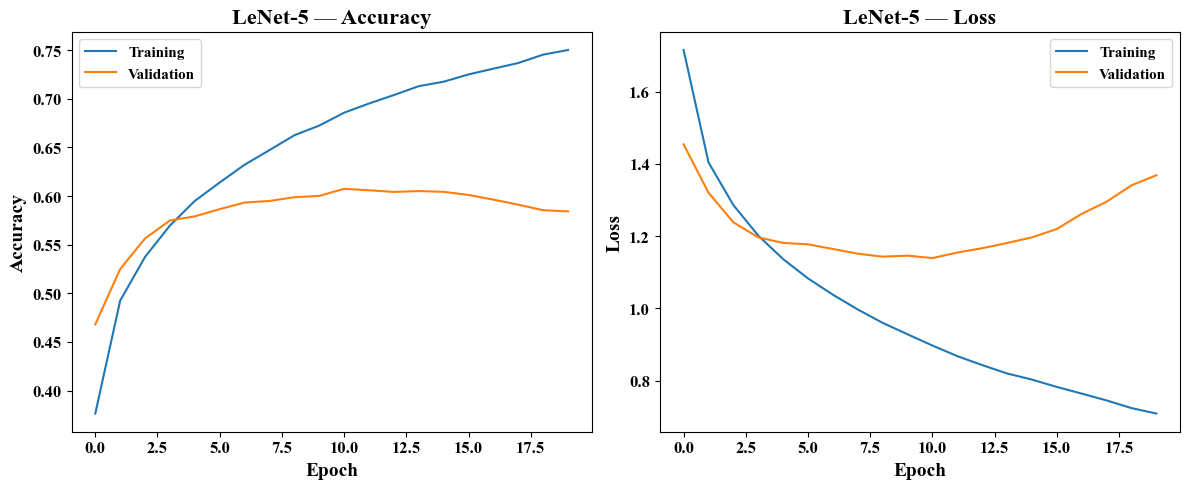


=== LeNet-5 — Test Set Performance ===
Accuracy: 0.5842  Precision: 0.6053  Recall: 0.5842  F1: 0.5882
              precision    recall  f1-score   support

    Airplane       0.64      0.69      0.66      1000
  Automobile       0.81      0.56      0.66      1000
        Bird       0.51      0.45      0.48      1000
         Cat       0.41      0.40      0.41      1000
        Deer       0.51      0.59      0.55      1000
         Dog       0.41      0.62      0.50      1000
        Frog       0.67      0.67      0.67      1000
       Horse       0.62      0.66      0.64      1000
        Ship       0.80      0.62      0.70      1000
       Truck       0.67      0.57      0.61      1000

    accuracy                           0.58     10000
   macro avg       0.61      0.58      0.59     10000
weighted avg       0.61      0.58      0.59     10000



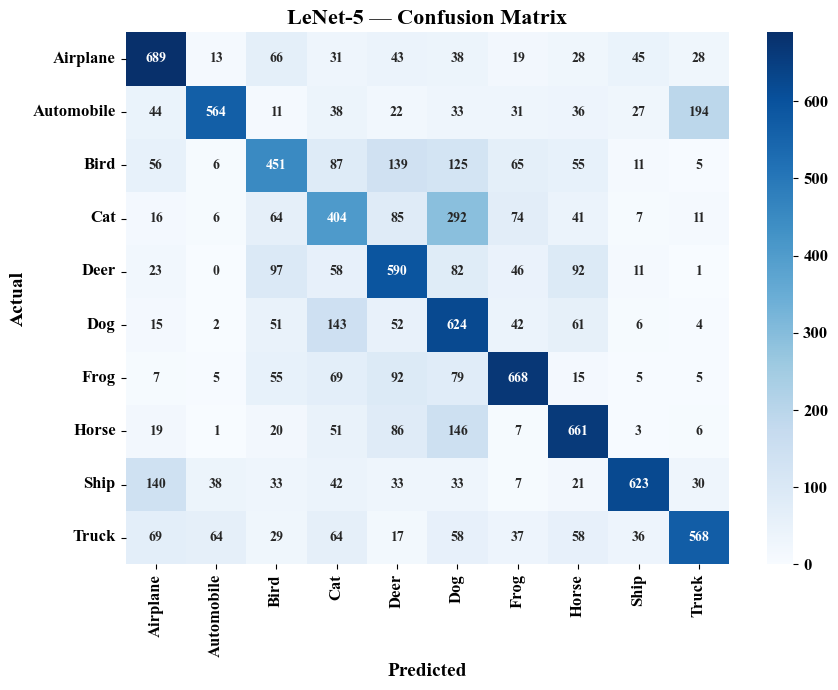

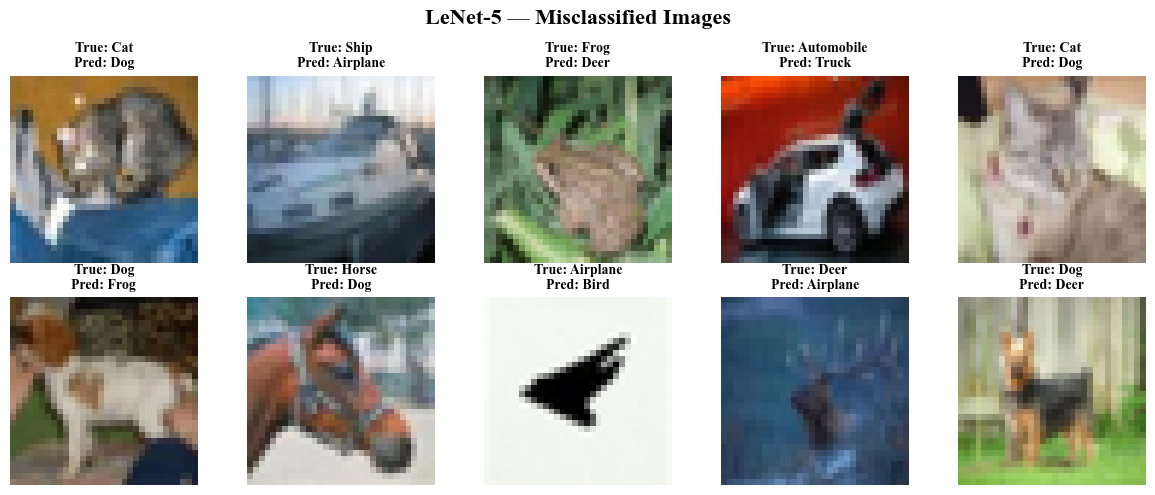

Checkpointed: LeNet-5



In [3]:
# --- LeNet-5 ---
def build_lenet5():
    return models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(6, (5, 5), activation='relu', padding='same'),
        layers.AveragePooling2D((2, 2)),
        layers.Conv2D(16, (5, 5), activation='relu'),
        layers.AveragePooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(10, activation='softmax', dtype='float32'),
    ], name="LeNet5")

train_ds_32 = build_tf_dataset(x_train, y_train, 32, None, training=True, cache_name="train32")
test_ds_32  = build_tf_dataset(x_test, y_test, 32, None, training=False, cache_name="test32")

lenet = build_lenet5()
lenet.compile(optimizer=optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
hist_lenet, t_lenet = train_and_time(lenet, train_ds_32, test_ds_32, 20, "LeNet-5")
plot_training_curves(hist_lenet.history, "LeNet-5")
m_lenet = evaluate_model(lenet, test_ds_32, y_test, "LeNet-5")
plot_misclassified(lenet, test_ds_32, x_test, y_test, "LeNet-5")

append_result_row({"Model": "LeNet-5", "Parameters": lenet.count_params(),
                    "Accuracy (%)": round(m_lenet["accuracy"]*100, 2), "Training Time (min)": round(t_lenet/60, 2)})
free_memory(lenet)

In [ ]:
# --- AlexNet (CIFAR-adapted) ---
def build_alexnet_cifar():
    return models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(96, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(384, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(384, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(1024, activation='relu'), layers.Dropout(0.5),
        layers.Dense(1024, activation='relu'), layers.Dropout(0.5),
        layers.Dense(10, activation='softmax', dtype='float32'),
    ], name="AlexNet_CIFAR")

# reload the 32x32 datasets fresh (kernel wasn't restarted within Part 1, but
# rebuilding is cheap and avoids any risk of a stale cache handle after the
# previous free_memory() call cleared the Keras session)
train_ds_32 = build_tf_dataset(x_train, y_train, 32, None, training=True, cache_name="train32")
test_ds_32  = build_tf_dataset(x_test, y_test, 32, None, training=False, cache_name="test32")

alexnet = build_alexnet_cifar()
alexnet.compile(optimizer=optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
hist_alexnet, t_alexnet = train_and_time(alexnet, train_ds_32, test_ds_32, 20, "AlexNet")
plot_training_curves(hist_alexnet.history, "AlexNet")
m_alexnet = evaluate_model(alexnet, test_ds_32, y_test, "AlexNet")
plot_misclassified(alexnet, test_ds_32, x_test, y_test, "AlexNet")

append_result_row({"Model": "AlexNet", "Parameters": alexnet.count_params(),
                    "Accuracy (%)": round(m_alexnet["accuracy"]*100, 2), "Training Time (min)": round(t_alexnet/60, 2)})
free_memory(alexnet)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 484s 613ms/step - accuracy: 0.2682 - loss: 1.9234 - val_accuracy: 0.5252 - val_loss: 1.2988
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 439s 561ms/step - accuracy: 0.5355 - loss: 1.2935 - val_accuracy: 0.6212 - val_loss: 1.0732
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 413s 528ms/step - accuracy: 0.6158 - loss: 1.0817 - val_accuracy: 0.6639 - val_loss: 0.9615
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 386s 494ms/step - accuracy: 0.6727 - loss: 0.9330 - val_accuracy: 0.6894 - val_loss: 0.9021
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 391s 500ms/step - accuracy: 0.7135 - loss: 0.8241 - val_accuracy: 0.6875 - val_loss: 0.9249
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 379s 485ms/step - accuracy: 0.7387 - loss: 0.7521 - val_accuracy: 0.7016 - val_loss: 0.9061
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 401s 513ms/step - accuracy: 0.7615 - loss: 0.6879 - val_accuracy: 0.7068 - val_loss: 0.8950
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 386s 494ms/step - accuracy: 0.7879 -

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 155s 179ms/step - accuracy: 0.2642 - loss: 1.9445 - val_accuracy: 0.5158 - val_loss: 1.2997
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 138s 177ms/step - accuracy: 0.5308 - loss: 1.2816 - val_accuracy: 0.6251 - val_loss: 1.0468
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 145s 186ms/step - accuracy: 0.6359 - loss: 1.0142 - val_accuracy: 0.6500 - val_loss: 0.9539
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 148s 190ms/step - accuracy: 0.6982 - loss: 0.8489 - val_accuracy: 0.7000 - val_loss: 0.8408
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 136s 174ms/step - accuracy: 0.7438 - loss: 0.7257 - val_accuracy: 0.7115 - val_loss: 0.8289
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 137s 175ms/step - accuracy: 0.7804 - loss: 0.6236 - val_accuracy: 0.7304 - val_loss: 0.7885
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 139s 177ms/step - accuracy: 0.8102 - loss: 0.5467 - val_accuracy: 0.7348 - val_loss: 0.8085
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 139s 177ms/step - accuracy: 0.8233 -

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


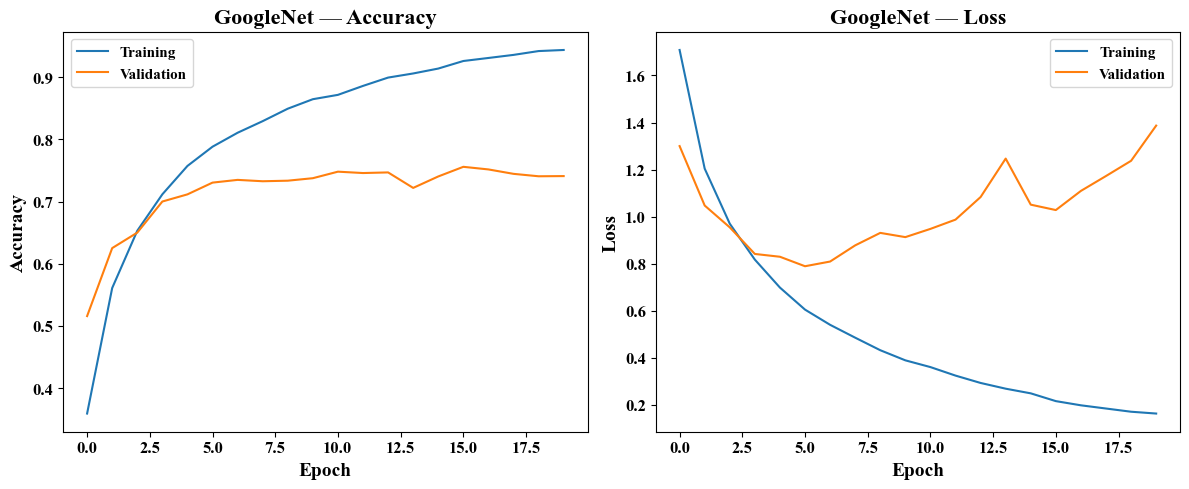


=== GoogleNet — Test Set Performance ===
Accuracy: 0.7409  Precision: 0.7471  Recall: 0.7409  F1: 0.7385
              precision    recall  f1-score   support

    Airplane       0.70      0.85      0.77      1000
  Automobile       0.92      0.81      0.86      1000
        Bird       0.78      0.58      0.67      1000
         Cat       0.59      0.51      0.54      1000
        Deer       0.71      0.65      0.68      1000
         Dog       0.66      0.66      0.66      1000
        Frog       0.84      0.76      0.80      1000
       Horse       0.65      0.89      0.75      1000
        Ship       0.87      0.83      0.85      1000
       Truck       0.75      0.88      0.81      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



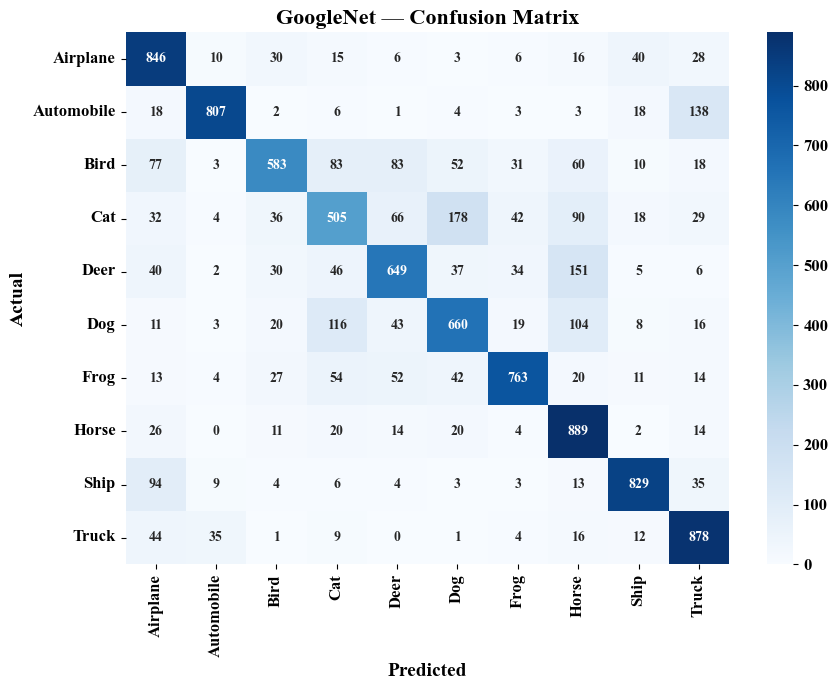

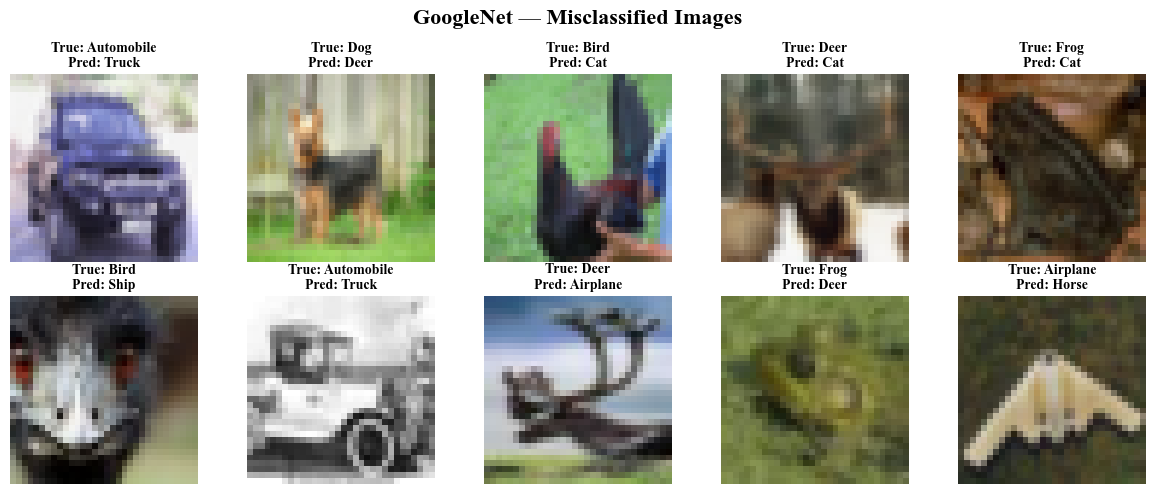

Checkpointed: GoogleNet

Part 1 complete. Checkpointed rows so far:
       Model  Parameters  Accuracy (%)  Training Time (min)
0    LeNet-5       83126         57.37                 2.66
1    LeNet-5       83126         58.42                 3.21
2    AlexNet     8576906         72.63               139.47
3  GoogleNet     1499634         74.09                46.29


In [5]:
# --- GoogleNet (real Inception modules, CIFAR-adapted) ---
def inception_module(x, f_1x1, f_3x3_reduce, f_3x3, f_5x5_reduce, f_5x5, f_pool_proj, name):
    b1 = layers.Conv2D(f_1x1, (1,1), padding='same', activation='relu')(x)
    b2 = layers.Conv2D(f_3x3_reduce, (1,1), padding='same', activation='relu')(x)
    b2 = layers.Conv2D(f_3x3, (3,3), padding='same', activation='relu')(b2)
    b3 = layers.Conv2D(f_5x5_reduce, (1,1), padding='same', activation='relu')(x)
    b3 = layers.Conv2D(f_5x5, (5,5), padding='same', activation='relu')(b3)
    b4 = layers.MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    b4 = layers.Conv2D(f_pool_proj, (1,1), padding='same', activation='relu')(b4)
    return layers.Concatenate(name=name)([b1, b2, b3, b4])

def build_googlenet_cifar():
    inputs = layers.Input(shape=(32, 32, 3))
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64, (1,1), padding='same', activation='relu')(x)
    x = layers.Conv2D(192, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = inception_module(x, 64, 96, 128, 16, 32, 32, 'inception_3a')
    x = inception_module(x, 128, 128, 192, 32, 96, 64, 'inception_3b')
    x = layers.MaxPooling2D((2,2))(x)
    x = inception_module(x, 192, 96, 208, 16, 48, 64, 'inception_4a')
    x = inception_module(x, 160, 112, 224, 24, 64, 64, 'inception_4b')
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(10, activation='softmax', dtype='float32')(x)
    return models.Model(inputs, outputs, name="GoogleNet_CIFAR")

train_ds_32 = build_tf_dataset(x_train, y_train, 32, None, training=True, cache_name="train32")
test_ds_32  = build_tf_dataset(x_test, y_test, 32, None, training=False, cache_name="test32")

googlenet = build_googlenet_cifar()
googlenet.compile(optimizer=optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
hist_googlenet, t_googlenet = train_and_time(googlenet, train_ds_32, test_ds_32, 20, "GoogleNet")
plot_training_curves(hist_googlenet.history, "GoogleNet")
m_googlenet = evaluate_model(googlenet, test_ds_32, y_test, "GoogleNet")
plot_misclassified(googlenet, test_ds_32, x_test, y_test, "GoogleNet")

append_result_row({"Model": "GoogleNet", "Parameters": googlenet.count_params(),
                    "Accuracy (%)": round(m_googlenet["accuracy"]*100, 2), "Training Time (min)": round(t_googlenet/60, 2)})
free_memory(googlenet)

print("\nPart 1 complete. Checkpointed rows so far:")
print(pd.read_csv(RESULTS_CSV))

Model: "AlexNet_CIFAR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 96)          │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 96)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 256)         │         221,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 384)           │         885,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 384)           │       1,327,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 256)           │         884,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │       4,195,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1024)                │       1,049,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │          10,250 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,576,906 (32.72 MB)

 Trainable params: 8,576,906 (32.72 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 390s 498ms/step - accuracy: 0.5191 - loss: 1.3172 - val_accuracy: 0.6160 - val_loss: 1.0766
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 375s 480ms/step - accuracy: 0.6170 - loss: 1.0834 - val_accuracy: 0.6626 - val_loss: 0.9544
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 379s 485ms/step - accuracy: 0.6731 - loss: 0.9382 - val_accuracy: 0.6892 - val_loss: 0.8854
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 383s 490ms/step - accuracy: 0.7094 - loss: 0.8341 - val_accuracy: 0.6870 - val_loss: 0.8918
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 382s 489ms/step - accuracy: 0.7388 - loss: 0.7441 - val_accuracy: 0.7166 - val_loss: 0.8296
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 373s 477ms/step - accuracy: 0.7653 - loss: 0.6762 - val_accuracy: 0.7158 - val_loss: 0.8481
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 373s 477ms/step - accuracy: 0.7829 - loss: 0.6216 - val_accuracy: 0.7049 - val_loss: 0.8833
Epoch 9/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 381s 487ms/step - accuracy: 0.7980 -

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


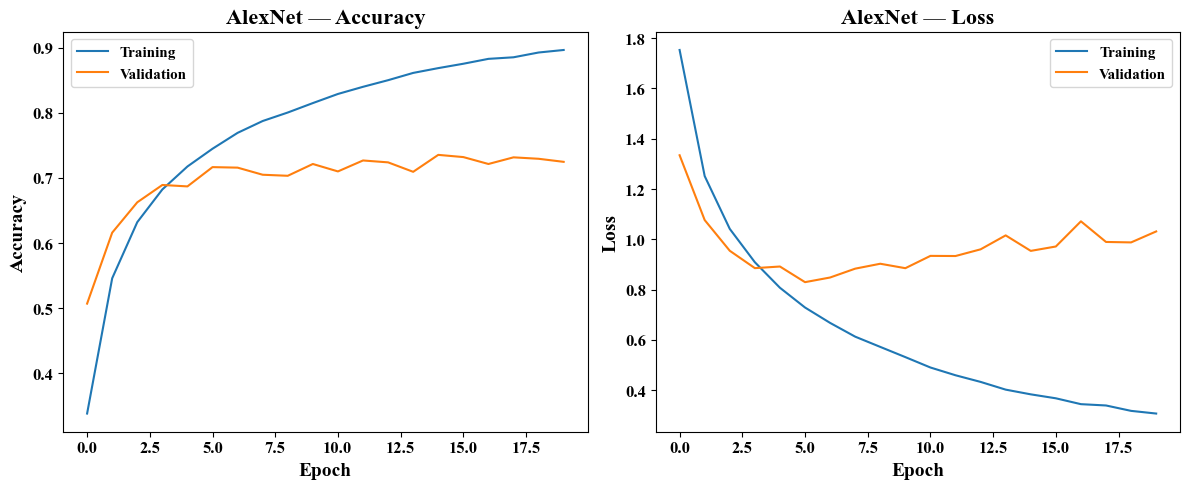


=== AlexNet — Test Set Performance ===
Accuracy: 0.7247  Precision: 0.7252  Recall: 0.7247  F1: 0.7199
              precision    recall  f1-score   support

    Airplane       0.69      0.82      0.75      1000
  Automobile       0.82      0.88      0.85      1000
        Bird       0.66      0.59      0.62      1000
         Cat       0.53      0.54      0.53      1000
        Deer       0.69      0.66      0.68      1000
         Dog       0.73      0.47      0.57      1000
        Frog       0.69      0.87      0.77      1000
       Horse       0.80      0.76      0.78      1000
        Ship       0.80      0.86      0.83      1000
       Truck       0.83      0.81      0.82      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.72      0.72     10000



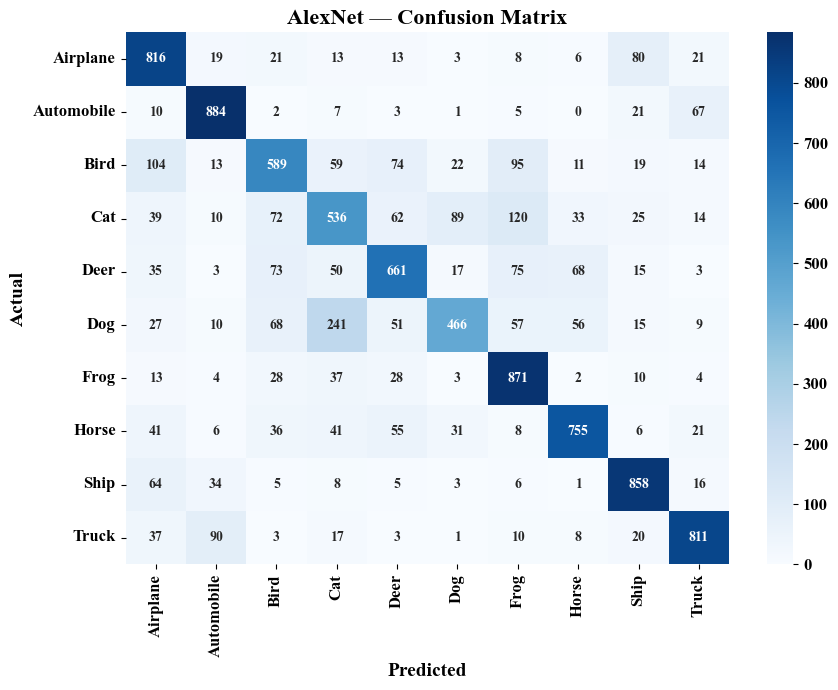

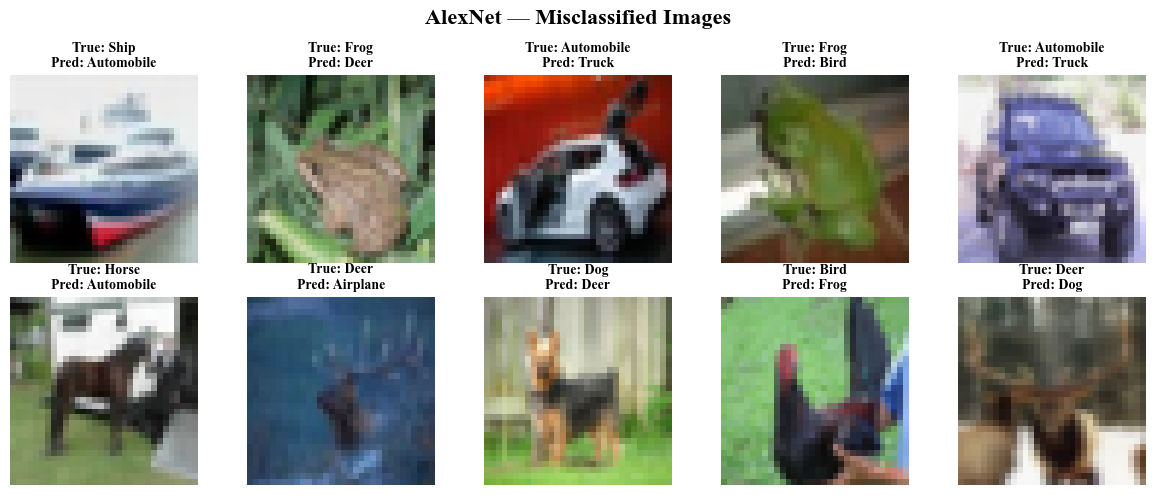

NameError: name 'results_table' is not defined

In [6]:
def build_alexnet_cifar():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(96, (3, 3), strides=1, activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(384, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(384, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax', dtype='float32'),
    ], name="AlexNet_CIFAR")
    return model

alexnet = build_alexnet_cifar()
alexnet.summary()
alexnet.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                 loss='categorical_crossentropy', metrics=['accuracy'])

hist_alexnet, time_alexnet = train_and_time(alexnet, train_ds_32, test_ds_32, epochs=20, model_name="AlexNet")
plot_training_curves(hist_alexnet.history, "AlexNet")
metrics_alexnet = evaluate_model(alexnet, test_ds_32, y_test, "AlexNet")
_ = plot_misclassified(alexnet, test_ds_32, x_test, y_test, "AlexNet")

results_table.append({
    "Model": "AlexNet",
    "Parameters": alexnet.count_params(),
    "Accuracy (%)": round(metrics_alexnet["accuracy"] * 100, 2),
    "Training Time (min)": round(time_alexnet / 60, 2),
})

In [7]:
def build_transfer_model(base_class, img_size, dense_units=256):
    base = base_class(input_shape=(img_size, img_size, 3), include_top=False, weights='imagenet')
    base.trainable = False
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation='softmax', dtype='float32')(x)
    return models.Model(inputs, outputs), base

def run_transfer_pipeline(base_class, preprocess_fn, img_size, model_name,
                           frozen_epochs=10, fine_tune_epochs=8, unfreeze_fraction=0.2):
    train_ds = build_tf_dataset(x_train, y_train, img_size, preprocess_fn, training=True,
                                 cache_name=f"{model_name}_train")
    test_ds  = build_tf_dataset(x_test, y_test, img_size, preprocess_fn, training=False,
                                 cache_name=f"{model_name}_test")

    model, base = build_transfer_model(base_class, img_size)
    model.compile(optimizer=optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    hist1, t1 = train_and_time(model, train_ds, test_ds, frozen_epochs, f"{model_name} (frozen)")

    base.trainable = True
    n_layers = len(base.layers)
    freeze_until = int(n_layers * (1 - unfreeze_fraction))
    for layer in base.layers[:freeze_until]:
        layer.trainable = False
    print(f"  [{model_name}] {n_layers} layers, {n_layers - freeze_until} unfrozen for fine-tuning")

    model.compile(optimizer=optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
    hist2, t2 = train_and_time(model, train_ds, test_ds, fine_tune_epochs, f"{model_name} (fine-tune)")

    merged = {k: hist1.history[k] + hist2.history[k] for k in hist1.history}
    plot_training_curves(merged, model_name, fine_tune_epoch=frozen_epochs)
    metrics = evaluate_model(model, test_ds, y_test, model_name)
    plot_misclassified(model, test_ds, x_test, y_test, model_name)

    total_time = t1 + t2
    append_result_row({"Model": model_name, "Parameters": model.count_params(),
                        "Accuracy (%)": round(metrics["accuracy"]*100, 2),
                        "Training Time (min)": round(total_time/60, 2)})

    return model, metrics, merged, total_time

IMG_SIZE_PRETRAINED = 96

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 1355s 2s/step - accuracy: 0.6513 - loss: 1.5870 - val_accuracy: 0.8061 - val_loss: 0.5724
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4013s 5s/step - accuracy: 0.8055 - loss: 0.5715 - val_accuracy: 0.8220 - val_loss: 0.5311
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 1308s 2s/step - accuracy: 0.8373 - loss: 0.4827 - val_accuracy: 0.8248 - val_loss: 0.5266
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 1304s 2s/step - accuracy: 0.8484 - loss: 0.4278 - val_accuracy: 0.8295 - val_loss: 0.5247
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 1295s 2s/step - accuracy: 0.8686 - loss: 0.3679 - val_accuracy: 0.8330 - val_loss: 0.5272
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 1239s 2s/step - accuracy: 0.8833 - loss: 0.3314 - val_accuracy: 0.8292 - val_loss: 0.5603
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 1220s 2s/step - accuracy: 0.8967 - loss: 0.2870 - val_accuracy: 0.8261 - val_loss: 0.5874
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 1238s 2s/step - accuracy: 0.9009 - loss: 0.2778 -

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


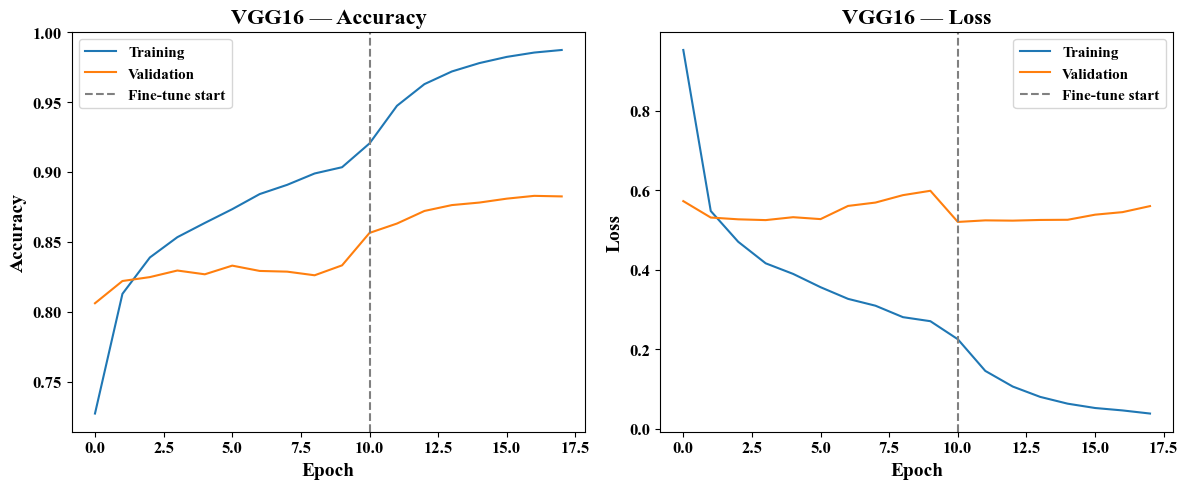


=== VGG16 — Test Set Performance ===
Accuracy: 0.8825  Precision: 0.8834  Recall: 0.8825  F1: 0.8819
              precision    recall  f1-score   support

    Airplane       0.92      0.89      0.90      1000
  Automobile       0.94      0.94      0.94      1000
        Bird       0.91      0.82      0.86      1000
         Cat       0.79      0.78      0.78      1000
        Deer       0.82      0.89      0.85      1000
         Dog       0.88      0.77      0.82      1000
        Frog       0.87      0.94      0.90      1000
       Horse       0.87      0.93      0.90      1000
        Ship       0.91      0.95      0.93      1000
       Truck       0.93      0.92      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



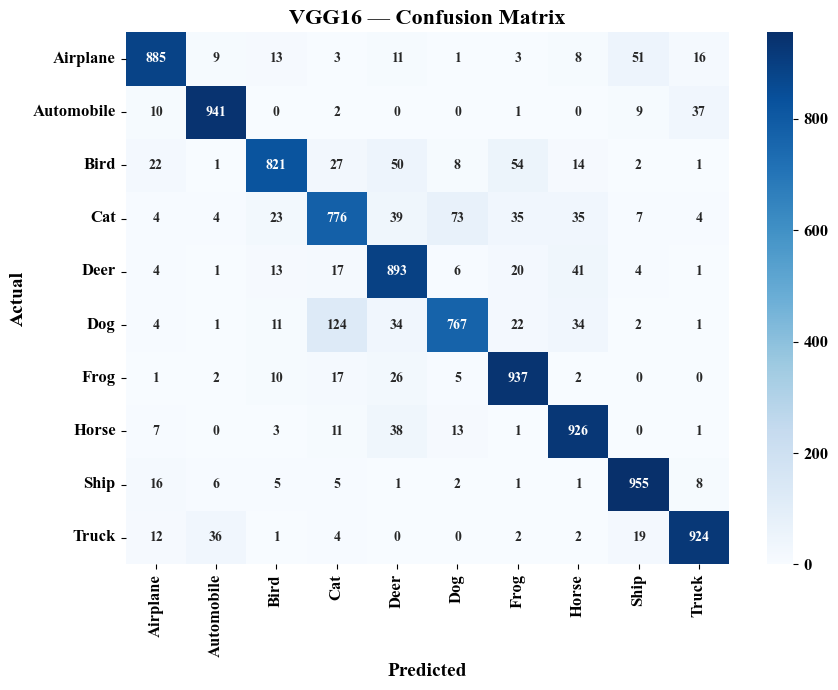

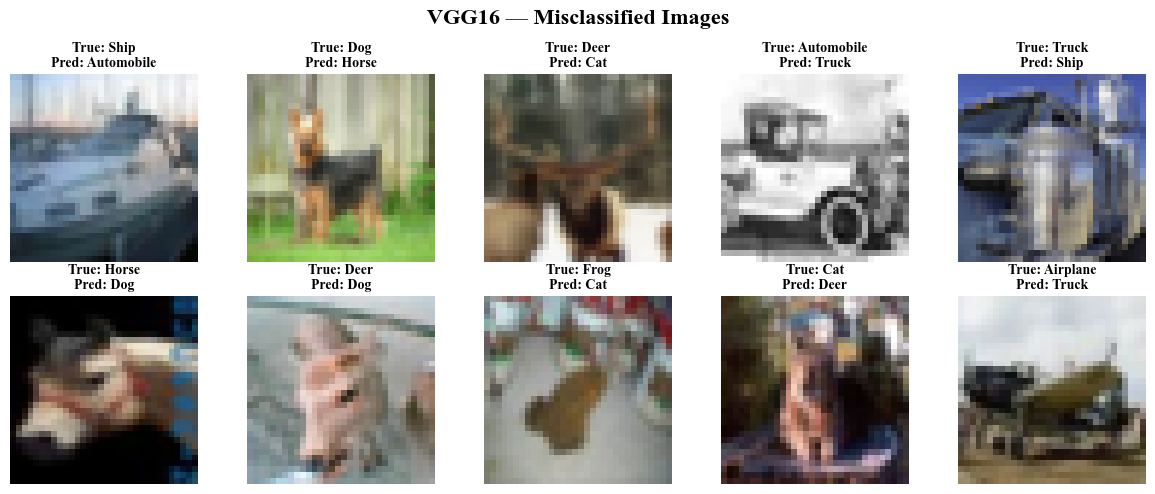

Checkpointed: VGG16

=== §18.1 Performance Metrics — VGG16 ===
             Metric      Value
  Training Accuracy     0.9872
   Testing Accuracy     0.8825
          Precision     0.8834
             Recall     0.8825
           F1-score     0.8819
Training Time (min)     760.91
   Total Parameters 14,848,586


In [10]:
# --- VGG16 (also the §18.1 primary model) ---
vgg_model, vgg_metrics, vgg_history, vgg_time_sec = run_transfer_pipeline(
    VGG16, vgg_preprocess, IMG_SIZE_PRETRAINED, "VGG16"
)

# §18.1 computed now, while vgg_model/vgg_history are still in memory —
# saved to disk so Part 2 doesn't need to be re-run to regenerate it
summary_181 = {
    "Metric": ["Training Accuracy", "Testing Accuracy", "Precision", "Recall",
               "F1-score", "Training Time (min)", "Total Parameters"],
    "Value": [
        round(vgg_history['accuracy'][-1], 4),
        round(vgg_metrics["accuracy"], 4),
        round(vgg_metrics["precision"], 4),
        round(vgg_metrics["recall"], 4),
        round(vgg_metrics["f1"], 4),
        round(vgg_time_sec/60, 2),
        f"{vgg_model.count_params():,}",
    ]
}
df_181 = pd.DataFrame(summary_181)
print("\n=== §18.1 Performance Metrics — VGG16 ===")
print(df_181.to_string(index=False))
df_181.to_csv("images/performance_summary_vgg16.csv", index=False)

free_memory(vgg_model)

In [ ]:
# --- ResNet50 ---
resnet_model, resnet_metrics, resnet_history, resnet_time_sec = run_transfer_pipeline(
    ResNet50, resnet_preprocess, IMG_SIZE_PRETRAINED, "ResNet50"
)
free_memory(resnet_model)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Epoch 1/10
 36/782 ━━━━━━━━━━━━━━━━━━━━ 9:43 783ms/step - accuracy: 0.4797 - loss: 2.2925

In [ ]:
# --- InceptionV3 (reference only — NOT used as the GoogleNet row; real
# GoogleNet with Inception modules is in Part 1) ---
inception_model, inception_metrics, inception_history, inception_time_sec = run_transfer_pipeline(
    InceptionV3, inception_preprocess, IMG_SIZE_PRETRAINED, "InceptionV3 (reference only)"
)
free_memory(inception_model)

In [ ]:
# --- §18.2 Final comparison table — loads ALL checkpointed rows from disk,
# so this works whether Part 1 ran in this session or a completely different one ---
df_results = pd.read_csv(RESULTS_CSV)
print(df_results.to_string(index=False))

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=df_results, x="Model", y="Accuracy (%)", palette="Blues_d")
make_bold_ticks(ax)
plt.title("Test Accuracy by Architecture", fontweight="bold")
plt.xticks(rotation=20)
plt.tight_layout()
save_figure("architecture_accuracy_comparison")
plt.show()

In [ ]:
def build_transfer_model_flexible(base_class, img_size, dense_units=256,
                                   frozen_mode='all', unfreeze_fraction=0.2):
    base = base_class(input_shape=(img_size, img_size, 3), include_top=False, weights='imagenet')
    if frozen_mode == 'all':
        base.trainable = False
    elif frozen_mode == 'partial':
        base.trainable = True
        n_layers = len(base.layers)
        freeze_until = int(n_layers * (1 - unfreeze_fraction))
        for layer in base.layers[:freeze_until]:
            layer.trainable = False
    else:
        raise ValueError("frozen_mode must be 'all' or 'partial'")

    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=(frozen_mode == 'partial'))
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation='softmax', dtype='float32')(x)
    return models.Model(inputs, outputs)

def get_optimizer(name, lr):
    if name == 'adam':
        return optimizers.Adam(learning_rate=lr)
    elif name == 'sgd':
        return optimizers.SGD(learning_rate=lr, momentum=0.9)
    raise ValueError("optimizer must be 'adam' or 'sgd'")

def run_hp_config(config, base_class=VGG16, preprocess_fn=vgg_preprocess, img_size=96):
    # cache_mode='skip' — one-shot sweep configs, caching would only add RAM/disk churn
    train_ds_hp = build_tf_dataset(x_train, y_train, img_size, preprocess_fn,
                                    batch_size=config['batch_size'], training=True, cache_mode="skip")
    test_ds_hp = build_tf_dataset(x_test, y_test, img_size, preprocess_fn,
                                   batch_size=config['batch_size'], training=False, cache_mode="skip")

    model_hp = build_transfer_model_flexible(base_class, img_size,
                                              dense_units=config['dense_units'],
                                              frozen_mode=config['frozen_mode'])
    model_hp.compile(optimizer=get_optimizer(config['optimizer'], config['lr']),
                      loss='categorical_crossentropy', metrics=['accuracy'])

    start = time.time()
    hist_hp = model_hp.fit(train_ds_hp, validation_data=test_ds_hp, epochs=config['epochs'], verbose=0)
    elapsed = time.time() - start

    result = {**config, "Val Accuracy": round(hist_hp.history['val_accuracy'][-1], 4),
              "Time/Epoch (s)": round(elapsed/config['epochs'], 1)}

    del model_hp, train_ds_hp, test_ds_hp, hist_hp
    tf.keras.backend.clear_session()
    gc.collect()
    return result

In [ ]:
baseline = {"lr": 0.001, "batch_size": 32, "epochs": 5,
            "optimizer": "adam", "dense_units": 256, "frozen_mode": "all"}

sweep_values = {
    "lr": [0.001, 0.0001], "batch_size": [32, 64], "epochs": [5, 10],
    "optimizer": ["adam", "sgd"], "dense_units": [128, 256], "frozen_mode": ["all", "partial"],
}

HP_CSV = "images/hyperparameter_study_full.csv"
hp_sweep_results = []

for param, values in sweep_values.items():
    for val in values:
        config = baseline.copy()
        config[param] = val
        config["varied_param"] = param
        result = run_hp_config(config)
        hp_sweep_results.append(result)
        # checkpoint after every single config — if this crashes mid-sweep,
        # you don't lose the configs that already finished
        pd.DataFrame(hp_sweep_results).to_csv(HP_CSV, index=False)
        print(f"[{param}={val}] val_acc={result['Val Accuracy']}, time/epoch={result['Time/Epoch (s)']}s")

df_hp_full = pd.read_csv(HP_CSV)
print(df_hp_full.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
param_labels = {"lr": "Learning Rate", "batch_size": "Batch Size", "epochs": "Epochs",
                "optimizer": "Optimizer", "dense_units": "Dense Units", "frozen_mode": "Frozen Layers"}

for ax, (param, label) in zip(axes.flat, param_labels.items()):
    subset = df_hp_full[df_hp_full["varied_param"] == param]
    ax.bar(subset[param].astype(str), subset["Val Accuracy"], color="#4C72B0")
    ax.set_title(label, fontweight="bold"); ax.set_ylabel("Val Accuracy")
    make_bold_ticks(ax)

plt.suptitle("Hyperparameter Sensitivity — VGG16 Baseline", fontweight="bold", fontsize=16)
plt.tight_layout()
save_figure("hyperparameter_sensitivity_grid")
plt.show()